In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from skimage.metrics import structural_similarity, mean_squared_error

In [ ]:
# Загрузка изображения в оттенках серого sar_1_gray.jpg
image = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')
plt.show()

histSize = 256
histRange = (0, 256)
accumulate = False

In [ ]:
# Обычная гистограмма
hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)
plt.plot(hist)
plt.show()

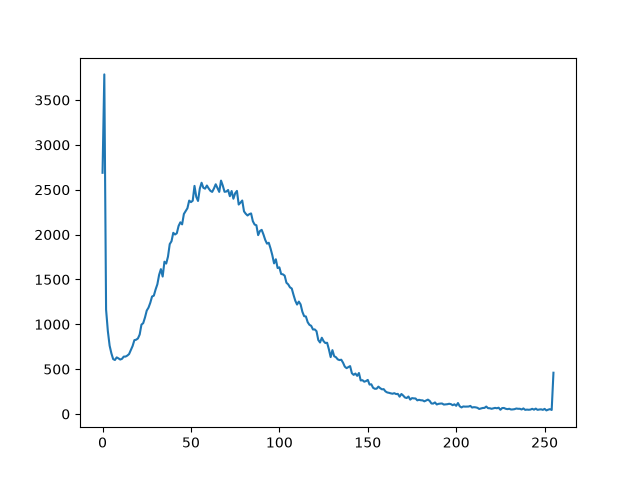

In [ ]:
# Кумутативная гистограмма
hist_cum = hist.cumsum()
plt.plot(hist_cum)
plt.show()

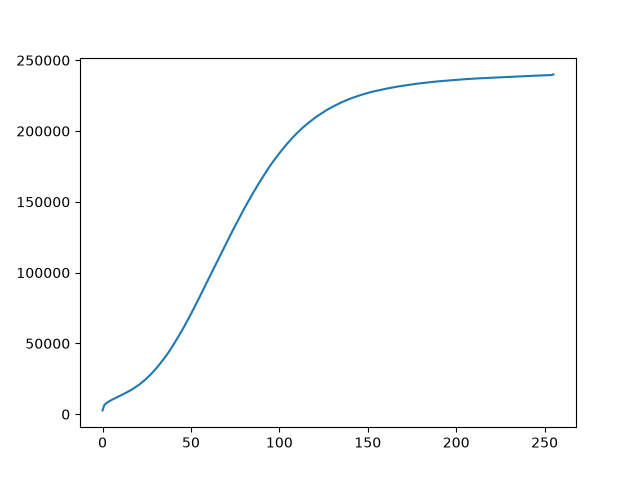

In [ ]:
# Нормированная гистограмма
hist_norm = hist /  (image.shape[0] * image.shape[1])
plt.plot(hist_norm)
plt.show()

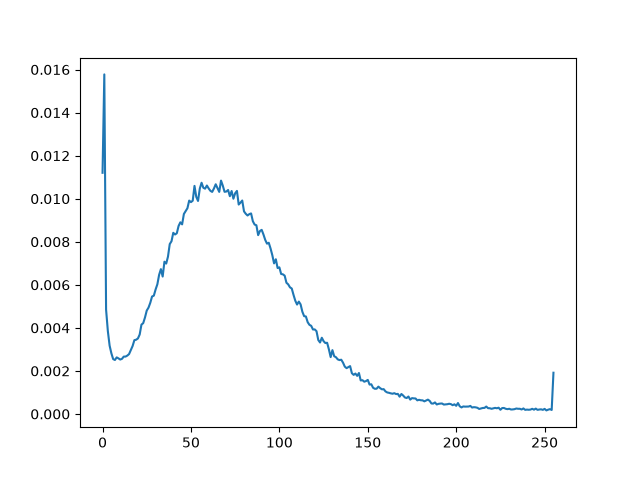

In [ ]:
# Гамма коррекция
def gamma_correction(img, gamma):
    # R_uncorrected / R_max
    img_norm = img.astype(np.float32) / 255.0
    
    # (...) ^ gamma
    img_gamma = np.power(img_norm, gamma)
    
    # (...) * R_max
    img_corrected = np.clip(img_gamma * 255.0, 0, 255).astype(np.uint8)
    
    return img_corrected


# < 1
gamma_low = 0.5
image_gamma_low = gamma_correction(image, gamma_low)

# > 1 
gamma_high = 2.5
image_gamma_high = gamma_correction(image, gamma_high)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Оригинал')
axes[0].axis('off')

axes[1].imshow(image_gamma_low, cmap='gray')
axes[1].set_title(f'Гамма = {gamma_low}')
axes[1].axis('off')

axes[2].imshow(image_gamma_high, cmap='gray')
axes[2].set_title(f'Гамма = {gamma_high}')
axes[2].axis('off')

plt.tight_layout()
plt.show()

(ssim_low, diff_low) = structural_similarity(image, image_gamma_low, full=True, data_range=255)
diff_low = (diff_low * 255).astype("uint8")
print(f"Гамма={gamma_low} (осветление): SSIM = {ssim_low:.4f}")

mse_low = mean_squared_error(image, image_gamma_low)
print(f"Гамма={gamma_low} (осветление): MSE  = {mse_low:.2f}")

(ssim_high, diff_high) = structural_similarity(image, image_gamma_high, full=True, data_range=255)
diff_high = (diff_high * 255).astype("uint8")
print(f"Гамма={gamma_high} (затемнение): SSIM = {ssim_high:.4f}")

mse_high = mean_squared_error(image, image_gamma_high)
print(f"Гамма={gamma_high} (затемнение): MSE  = {mse_high:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(diff_low)
axes[0].set_title(f'Карта различий, гамма = {gamma_low}')
axes[0].axis('off')

axes[1].imshow(diff_high)
axes[1].set_title(f'Карта различий, гамма = {gamma_high}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

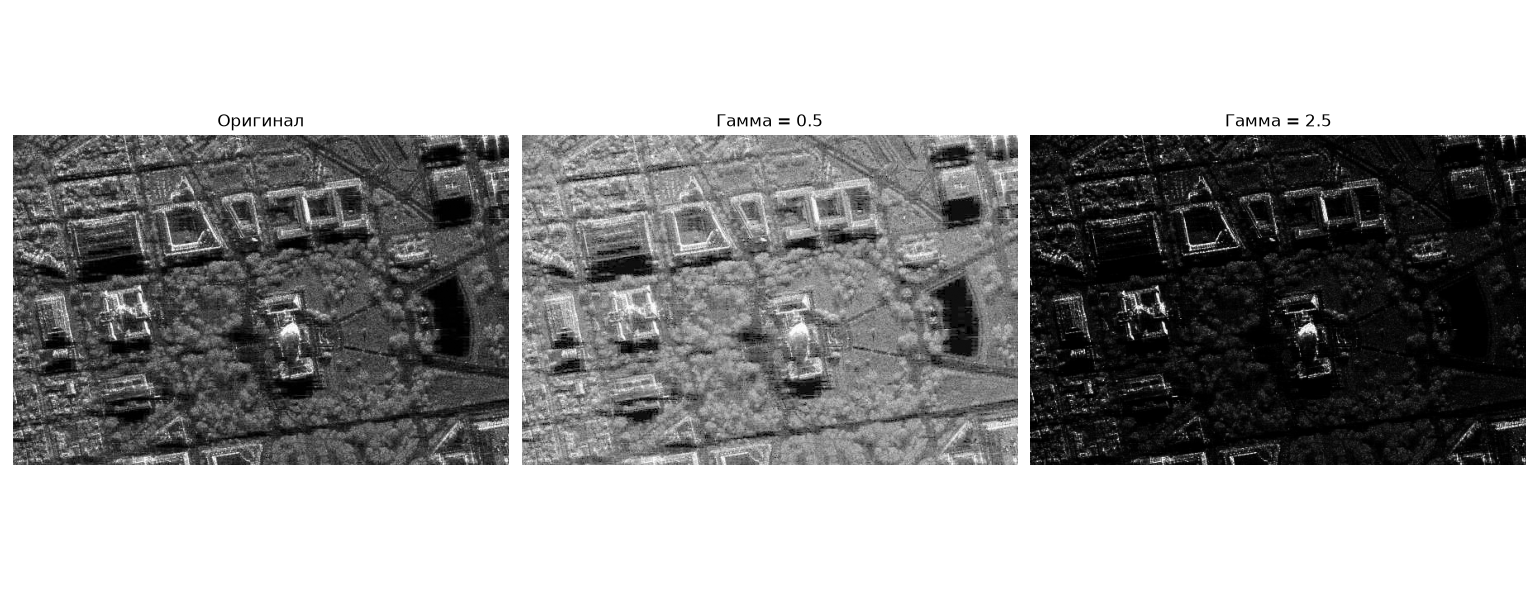

In [ ]:
# Сравнение исходного изображения, скорректированного при помощи гамма-фильтра. MSE, SSIM
(ssim_low, diff_low) = structural_similarity(image, image_gamma_low, full=True, data_range=255)
diff_low = (diff_low * 255).astype("uint8")
print(f"Гамма={gamma_low} (осветление): SSIM = {ssim_low:.4f}")

mse_low = mean_squared_error(image, image_gamma_low)
print(f"Гамма={gamma_low} (осветление): MSE  = {mse_low:.2f}")

(ssim_high, diff_high) = structural_similarity(image, image_gamma_high, full=True, data_range=255)
diff_high = (diff_high * 255).astype("uint8")
print(f"Гамма={gamma_high} (затемнение): SSIM = {ssim_high:.4f}")

mse_high = mean_squared_error(image, image_gamma_high)
print(f"Гамма={gamma_high} (затемнение): MSE  = {mse_high:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(diff_low)
axes[0].set_title(f'Карта различий, гамма = {gamma_low}')
axes[0].axis('off')

axes[1].imshow(diff_high)
axes[1].set_title(f'Карта различий, гамма = {gamma_high}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

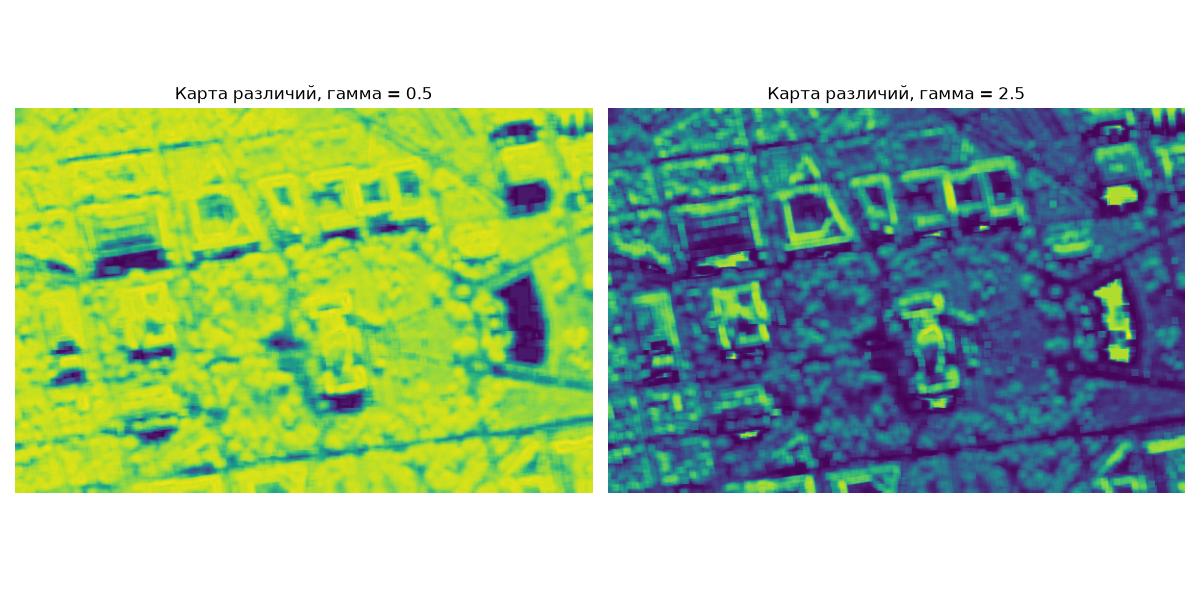

Гамма=0.5 (осветление): SSIM = 0.7875
Гамма=0.5 (осветление): MSE  = 3250.43
Гамма=2.5 (затемнение): SSIM = 0.3285
Гамма=2.5 (затемнение): MSE  = 3556.52

In [ ]:
# Алгоритм статистической цветокоррекции на основе статистики eq_gray
def my_equalize_hist(img):
    # гистограмма H(j)
    hist = np.bincount(img.ravel(), minlength=256)

    # кумулятивная функция распределения H'(i) = Σ_{j<i} H(j)
    cdf = hist.cumsum()

    # растяжение H' так, чтобы max = 255
    cdf_min = cdf[cdf > 0].min()
    N = img.size
    lut = np.round((cdf - cdf_min) / (N - cdf_min) * 255).astype(np.uint8)
    lut[cdf <= cdf_min] = 0

    # максимум таблицы = 255
    assert lut.max() == 255, f"lut.max() = {lut.max()}, ожидалось 255"

    # преобразование equalized(x,y) = H'(src(x,y))
    eq = lut[img]

    return eq

#eq_gray = cv2.equalizeHist(image)
eq_gray = my_equalize_hist(image)

plt.imshow(eq_gray, cmap='gray')
plt.title('eq_gray (equalizeHist)')
plt.axis('off')
plt.show()

E_s = eq_gray.mean()    # E_s
D_s = eq_gray.std()     # D_s
E_t = image.mean()      # E_t
D_t = image.std()       # D_t

print(f"source (eq_gray): E_s = {E_s:.2f}, D_s = {D_s:.2f}")
print(f"target (image):   E_t = {E_t:.2f}, D_t = {D_t:.2f}")

C_t_new = E_s + (image.astype(np.float32) - E_t) * (D_s / D_t)
image_stat = np.clip(C_t_new, 0, 255).astype(np.uint8)

print(f"result (image_stat): mean = {image_stat.mean():.2f}, std = {image_stat.std():.2f}")

plt.imshow(image_stat, cmap='gray')
plt.title('Статистическая цветокоррекция (по статистике eq_gray)')
plt.axis('off')
plt.show()

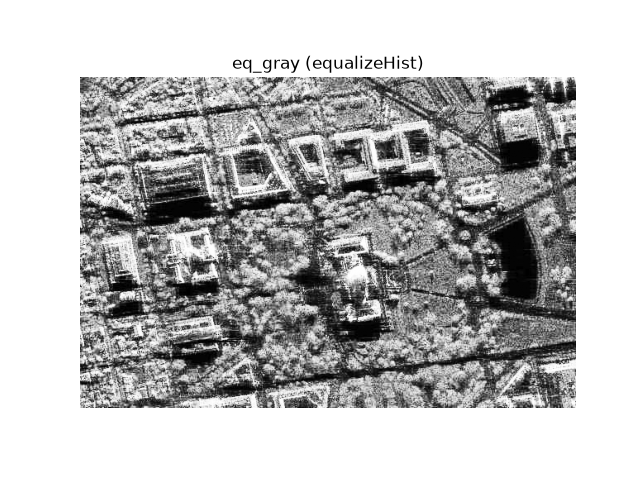

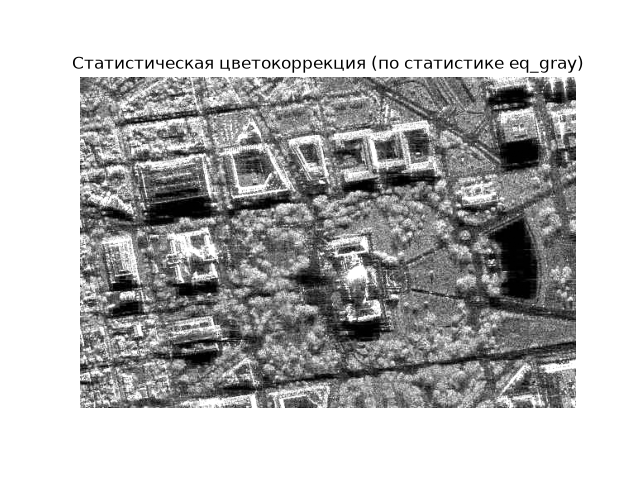

source (eq_gray): E_s = 127.03, D_s = 74.27
target (image):   E_t = 74.94, D_t = 43.66
result (image_stat): mean = 123.12, std = 65.30

In [ ]:
# Тест работы алгоритмов пороговой фильтрации с различными параметрами
threshold_values = [50, 125, 200]

In [ ]:
# 1. THRESH_BINARY
print("-" * 10)
print("THRESH_BINARY")
print(" " * 2)

fig, axes = plt.subplots(1, len(threshold_values) + 1, figsize=(22, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Оригинал')
axes[0].axis('off')

for ax, t in zip(axes[1:], threshold_values):
    _, thresh_bin = cv2.threshold(image, t, 255, cv2.THRESH_BINARY)
    # Проверка: значения в thresh_bin могут быть только 0 или 255
    unique_vals = np.unique(thresh_bin)
    n_255 = thresh_bin[thresh_bin == 255].sum()
    n_127 = thresh_bin[thresh_bin == 127].sum()
    print(f"t={t:3d}: unique = {unique_vals}, count(255) = {np.sum(thresh_bin == 255)}, "
          f"thresh_bin[thresh_bin==127].sum() = {n_127}")

    ax.imshow(thresh_bin, cmap='gray')
    ax.set_title(f'BINARY, t={t}')
    ax.axis('off')

plt.tight_layout()
plt.show()

----------
THRESH_BINARY
  
t= 50: unique = [  0 255], count(255) = 169178, thresh_bin[thresh_bin==127].sum() = 0
t=125: unique = [  0 255], count(255) = 26577, thresh_bin[thresh_bin==127].sum() = 0
t=200: unique = [  0 255], count(255) = 3830, thresh_bin[thresh_bin==127].sum() = 0

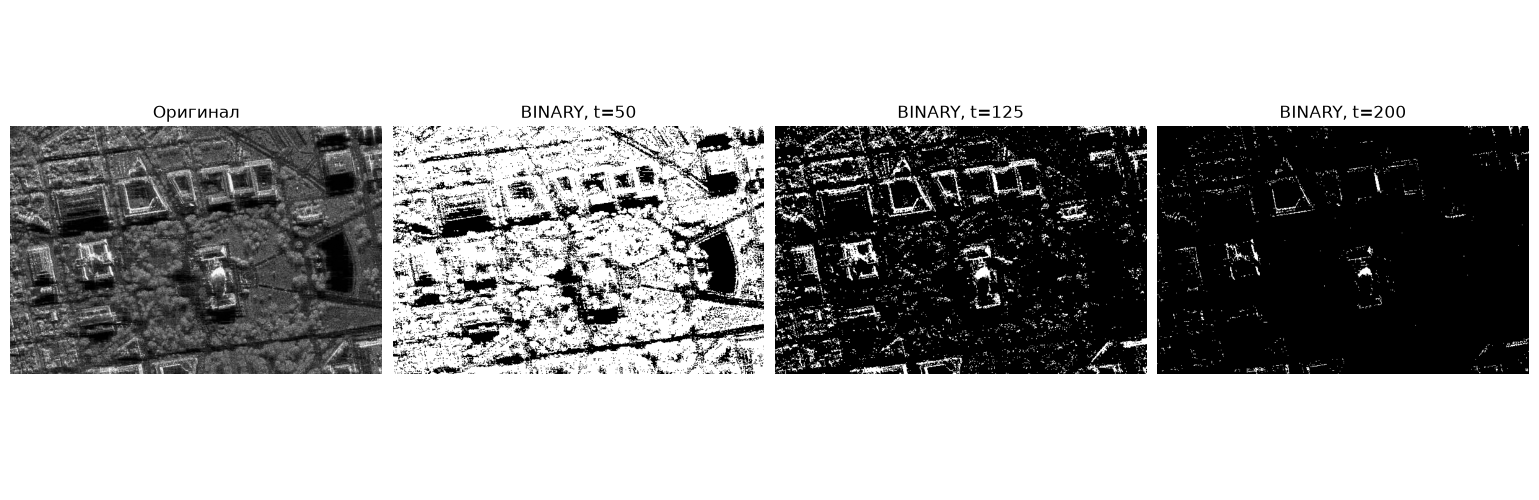

In [ ]:
# 2. THRESH_BINARY_INV
print("\n" + "-" * 10)
print("THRESH_BINARY_INV")
print(" " * 2)

fig, axes = plt.subplots(1, len(threshold_values) + 1, figsize=(22, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Оригинал')
axes[0].axis('off')

for ax, t in zip(axes[1:], threshold_values):
    _, thresh_bin_inv = cv2.threshold(image, t, 255, cv2.THRESH_BINARY_INV)
    
    # Проверка: должны быть только 0 и 255, значит n0 + n255 == image.size
    unique_vals = np.unique(thresh_bin_inv)

    n255 = np.sum(thresh_bin_inv == 255)
    n0   = np.sum(thresh_bin_inv == 0)

    print(f"t={t:3d}: unique = {unique_vals}, count(255) = {n255}, count(0) = {n0}, "
          f"n0 + n255 = {n0 + n255} == size = {image.size}")

    ax.imshow(thresh_bin_inv, cmap='gray')
    ax.set_title(f'BINARY_INV, t={t}')
    ax.axis('off')

plt.tight_layout()
plt.show()

----------
THRESH_BINARY_INV
  
t= 50: unique = [  0 255], count(255) = 70822, count(0) = 169178, n0 + n255 = 240000 == size = 240000
t=125: unique = [  0 255], count(255) = 213423, count(0) = 26577, n0 + n255 = 240000 == size = 240000
t=200: unique = [  0 255], count(255) = 236170, count(0) = 3830, n0 + n255 = 240000 == size = 240000

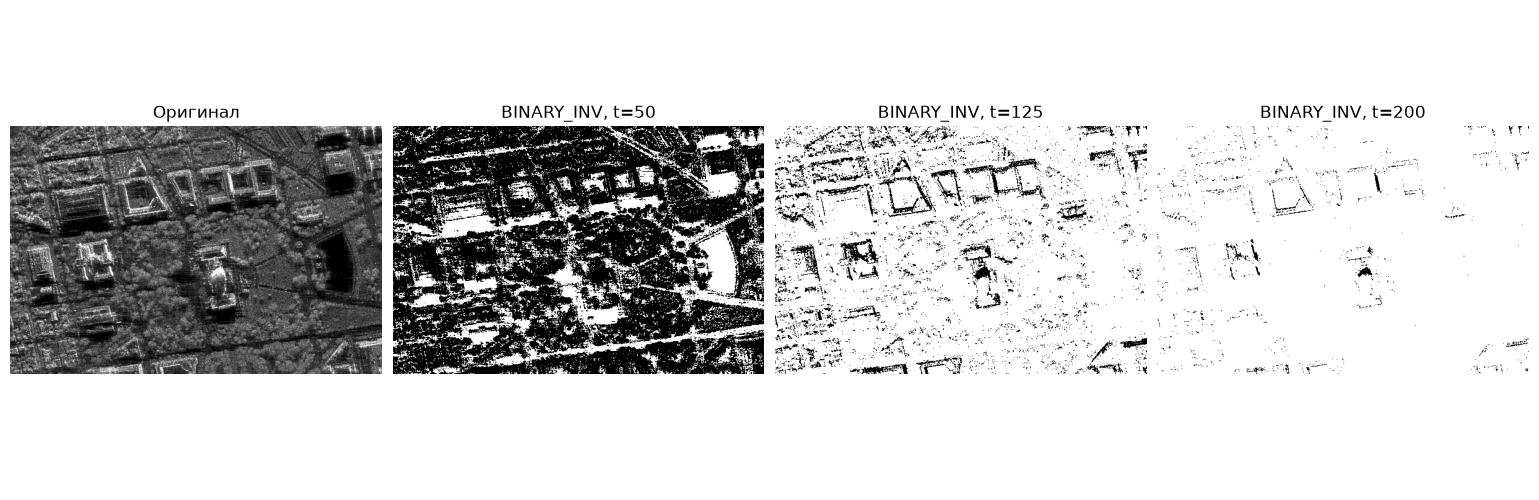

In [ ]:
# 3. THRESH_TRUNC
print("\n" + "-" * 10)
print("THRESH_TRUNC")
print(" " * 2)

fig, axes = plt.subplots(1, len(threshold_values) + 1, figsize=(22, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Оригинал')
axes[0].axis('off')

for ax, t in zip(axes[1:], threshold_values):
    _, thresh_trunc = cv2.threshold(image, t, 255, cv2.THRESH_TRUNC)
    unique_vals = np.unique(thresh_trunc)
    max_val = thresh_trunc.max()
    # Проверка: максимальное значение не должно превышать t
    print(f"t={t:3d}: max = {max_val}, уникальных значений = {len(unique_vals)}, "
          f"уникальных > t = {np.sum(unique_vals > t)}")

    ax.imshow(thresh_trunc, cmap='gray')
    ax.set_title(f'TRUNC, t={t}')
    ax.axis('off')

plt.tight_layout()
plt.show()

----------
THRESH_TRUNC
  
t= 50: max = 50, уникальных значений = 51, уникальных > t = 0
t=125: max = 125, уникальных значений = 126, уникальных > t = 0
t=200: max = 200, уникальных значений = 201, уникальных > t = 0

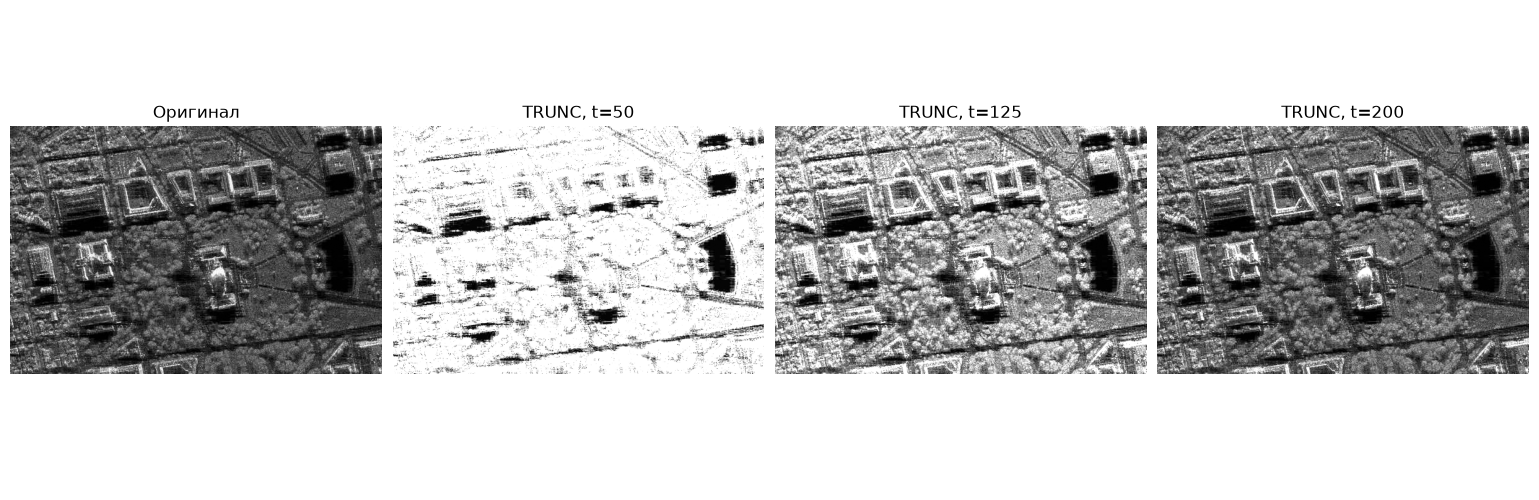

In [ ]:
# 4. THRESH_TOZERO 
print("\n" + "-" * 10)
print("THRESH_TOZERO")
print(" " * 2)

fig, axes = plt.subplots(1, len(threshold_values) + 1, figsize=(22, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Оригинал')
axes[0].axis('off')

for ax, t in zip(axes[1:], threshold_values):
    _, thresh_tozero = cv2.threshold(image, t, 255, cv2.THRESH_TOZERO)
    n_zeros = np.sum(thresh_tozero == 0)
    # Проверка: значения ниже порога должны были стать 0
    print(f"t={t:3d}: count(0) = {n_zeros}, max = {thresh_tozero.max()}, "
          f"min(ненулевых) = {thresh_tozero[thresh_tozero > 0].min() if np.any(thresh_tozero > 0) else 'N/A'}")

    ax.imshow(thresh_tozero, cmap='gray')
    ax.set_title(f'TOZERO, t={t}')
    ax.axis('off')

plt.tight_layout()
plt.show()

----------
THRESH_TOZERO
  
t= 50: count(0) = 70822, max = 255, min(ненулевых) = 51
t=125: count(0) = 213423, max = 255, min(ненулевых) = 126
t=200: count(0) = 236170, max = 255, min(ненулевых) = 201

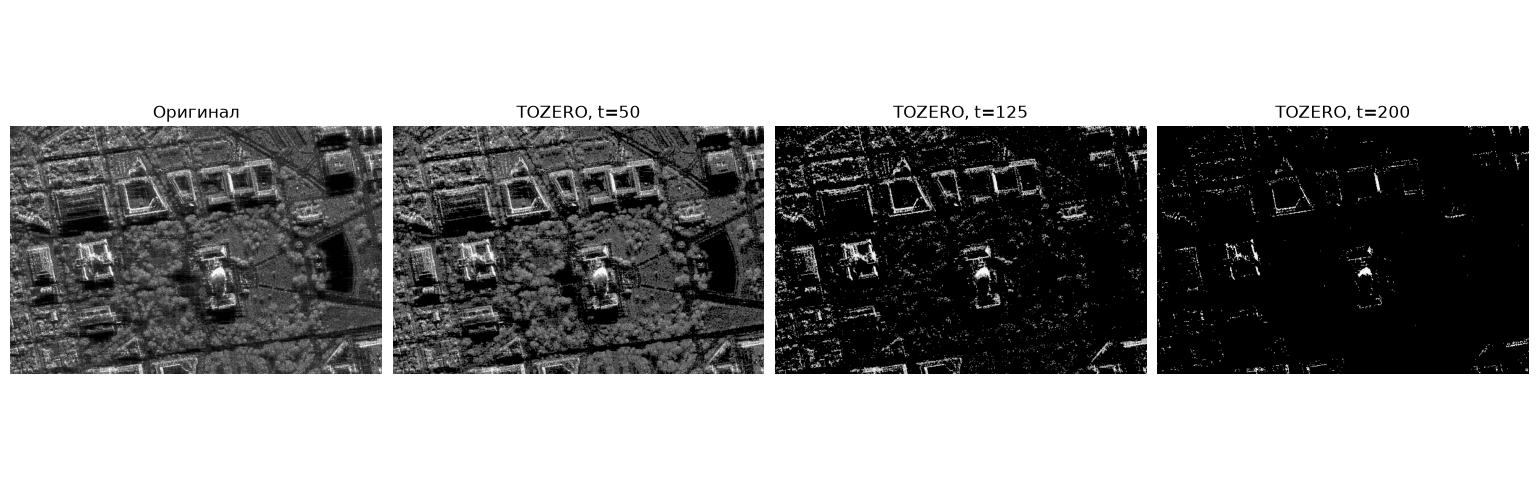

In [ ]:
# 5. THRESH_TOZERO_INV
print("\n" + "-" * 10)
print("THRESH_TOZERO_INV")
print(" " * 2)

fig, axes = plt.subplots(1, len(threshold_values) + 1, figsize=(22, 5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Оригинал')
axes[0].axis('off')

for ax, t in zip(axes[1:], threshold_values):
    _, thresh_tozero_inv = cv2.threshold(image, t, 255, cv2.THRESH_TOZERO_INV)
    n_zeros = np.sum(thresh_tozero_inv == 0)
    # Проверка: значения выше порога должны были стать 0
    print(f"t={t:3d}: count(0) = {n_zeros}, max = {thresh_tozero_inv.max()}, "
          f"max(ненулевых) = {thresh_tozero_inv[thresh_tozero_inv > 0].max() if np.any(thresh_tozero_inv > 0) else 'N/A'}")

    ax.imshow(thresh_tozero_inv, cmap='gray')
    ax.set_title(f'TOZERO_INV, t={t}')
    ax.axis('off')

plt.tight_layout()
plt.show()

----------
THRESH_TOZERO_INV
  
t= 50: count(0) = 171867, max = 50, max(ненулевых) = 50
t=125: count(0) = 29266, max = 125, max(ненулевых) = 125
t=200: count(0) = 6519, max = 200, max(ненулевых) = 200

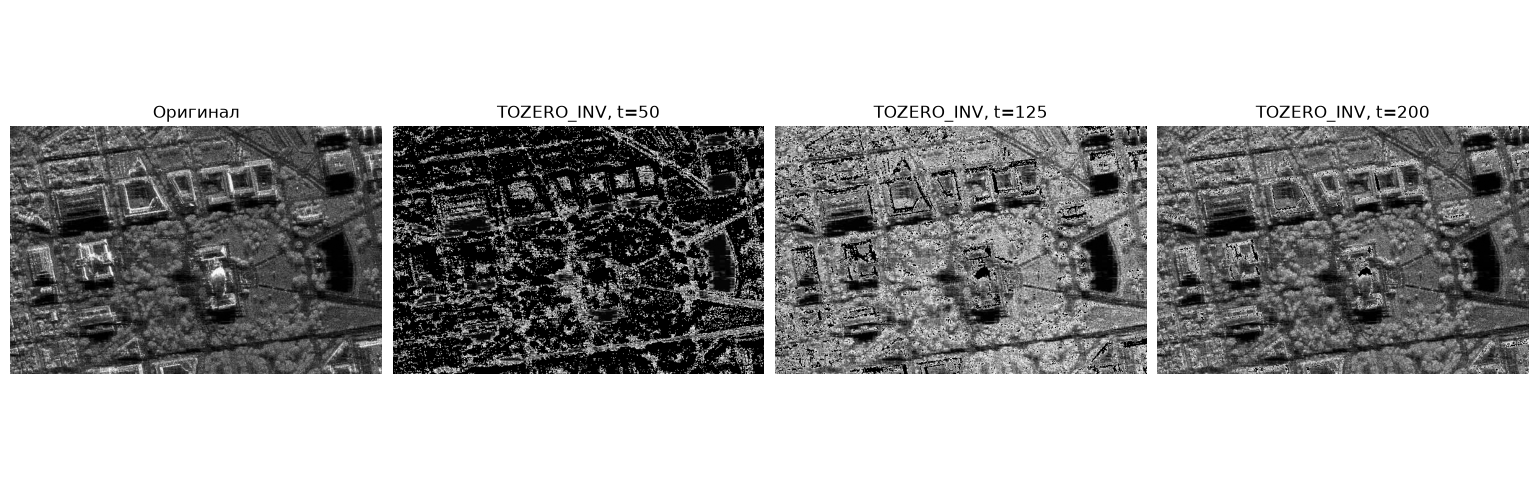